In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

In [ ]:
DATA_PATH = PROJECT_ROOT / 'data/processed/vehicles_cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.head()

In [ ]:
df

,id,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,paint_color,state,post_year,post_month,car_age,price_category,mileage_category,age_category,manufacturer_grouped,posting_season
0,7316356412,15000.0,2013,ford,f-150 xlt,excellent,6,gas,128000,clean,...,black,al,2021,5,8,Premium,Medium,Moderate,ford,Spring
1,7306407989,17500.0,2008,toyota,fj cruiser,good,6,gas,201300,clean,...,black,al,2021,4,13,Premium,High,Old,toyota,Spring
2,7302286548,28000.0,2018,acura,tlx,excellent,6,gas,55000,clean,...,white,al,2021,4,3,Premium,Medium,New,other,Spring
3,7316852517,21250.0,2002,ford,thunderbird,new,8,gas,15996,clean,...,yellow,al,2021,5,19,Premium,Low,Old,ford,Spring
4,7316673788,3750.0,1997,ford,f150,excellent,6,gas,150000,clean,...,unknown,al,2021,5,24,Budget,High,Old,ford,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27982,7305798116,1800.0,1997,toyota,4runner,good,6,gas,239000,clean,...,white,wy,2021,4,24,Budget,High,Old,toyota,Spring
27983,7305718110,6500.0,2002,ford,f 350,excellent,6,diesel,295000,clean,...,unknown,wy,2021,4,19,Mid-range,High,Old,ford,Spring
27984,7305596553,2800.0,2000,chevrolet,s10 pickup,excellent,6,gas,140000,clean,...,unknown,wy,2021,4,21,Budget,Medium,Old,chevrolet,Spring
27985,7305590558,9000.0,2015,jeep,wrangler unlimited,salvage,6,gas,73000,salvage,...,black,wy,2021,4,6,Mid-range,Medium,Moderate,jeep,Spring


## Exploratory Data Analysis

In [ ]:
print('--- Head of DataFrame ---')
display(df.head())

--- Head of DataFrame ---


,id,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,paint_color,state,post_year,post_month,car_age,price_category,mileage_category,age_category,manufacturer_grouped,posting_season
0,7316356412,15000.0,2013,ford,f-150 xlt,excellent,6,gas,128000,clean,...,black,al,2021,5,8,Premium,Medium,Moderate,ford,Spring
1,7306407989,17500.0,2008,toyota,fj cruiser,good,6,gas,201300,clean,...,black,al,2021,4,13,Premium,High,Old,toyota,Spring
2,7302286548,28000.0,2018,acura,tlx,excellent,6,gas,55000,clean,...,white,al,2021,4,3,Premium,Medium,New,other,Spring
3,7316852517,21250.0,2002,ford,thunderbird,new,8,gas,15996,clean,...,yellow,al,2021,5,19,Premium,Low,Old,ford,Spring
4,7316673788,3750.0,1997,ford,f150,excellent,6,gas,150000,clean,...,unknown,al,2021,5,24,Budget,High,Old,ford,Spring


In [ ]:
print('--- DataFrame Info ---')
print(df.info())

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27987 entries, 0 to 27986
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    27987 non-null  int64  
 1   price                 27987 non-null  float64
 2   year                  27987 non-null  int64  
 3   manufacturer          27987 non-null  object 
 4   model                 27987 non-null  object 
 5   condition             27987 non-null  object 
 6   cylinders             27987 non-null  int64  
 7   fuel                  27987 non-null  object 
 8   odometer              27987 non-null  int64  
 9   title_status          27987 non-null  object 
 10  transmission          27987 non-null  object 
 11  drive                 27987 non-null  object 
 12  type                  27987 non-null  object 
 13  paint_color           27987 non-null  object 
 14  state                 27987 non-null  object 
 

In [ ]:
print('--- Numerical Summary Statistics ---')
display(df.describe())

--- Numerical Summary Statistics ---


,id,price,year,cylinders,odometer,post_year,post_month,car_age
count,2.798700e+04,27987.000000,27987.000000,27987.000000,27987.000000,27987.0,27987.000000,27987.000000
mean,7.312165e+09,9678.966127,2007.633866,5.847036,133963.895094,2021.0,4.341909,13.366134
std,4.260590e+06,8909.490567,6.791268,1.349175,59039.550952,0.0,0.474358,6.791268
min,7.301589e+09,1500.000000,1980.000000,3.000000,500.000000,2021.0,4.000000,-1.000000
25%,7.309338e+09,4000.000000,2004.000000,4.000000,95633.000000,2021.0,4.000000,8.000000
50%,7.313634e+09,6750.000000,2008.000000,6.000000,133178.000000,2021.0,4.000000,13.000000
75%,7.315630e+09,11800.000000,2013.000000,6.000000,171135.000000,2021.0,5.000000,17.000000
max,7.317095e+09,56500.000000,2022.000000,12.000000,350962.000000,2021.0,5.000000,41.000000


In [ ]:
print('--- Categorical Summary Statistics ---')
display(df.describe(include='object'))

--- Categorical Summary Statistics ---


,manufacturer,model,condition,fuel,title_status,transmission,drive,type,paint_color,state,price_category,mileage_category,age_category,manufacturer_grouped,posting_season
count,27987,27987,27987,27987,27987,27987,27987,27987,27987,27987,27987,27987,27987,27987,27987
unique,42,5135,6,5,6,3,3,13,13,50,3,3,3,11,1
top,ford,unknown,excellent,gas,clean,automatic,fwd,sedan,unknown,ca,Mid-range,Medium,Old,other,Spring
freq,4361,585,15535,25725,25920,25298,11096,8585,9382,3156,13507,14723,17638,8378,27987


### 2. Univariate Analysis of Key Features


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

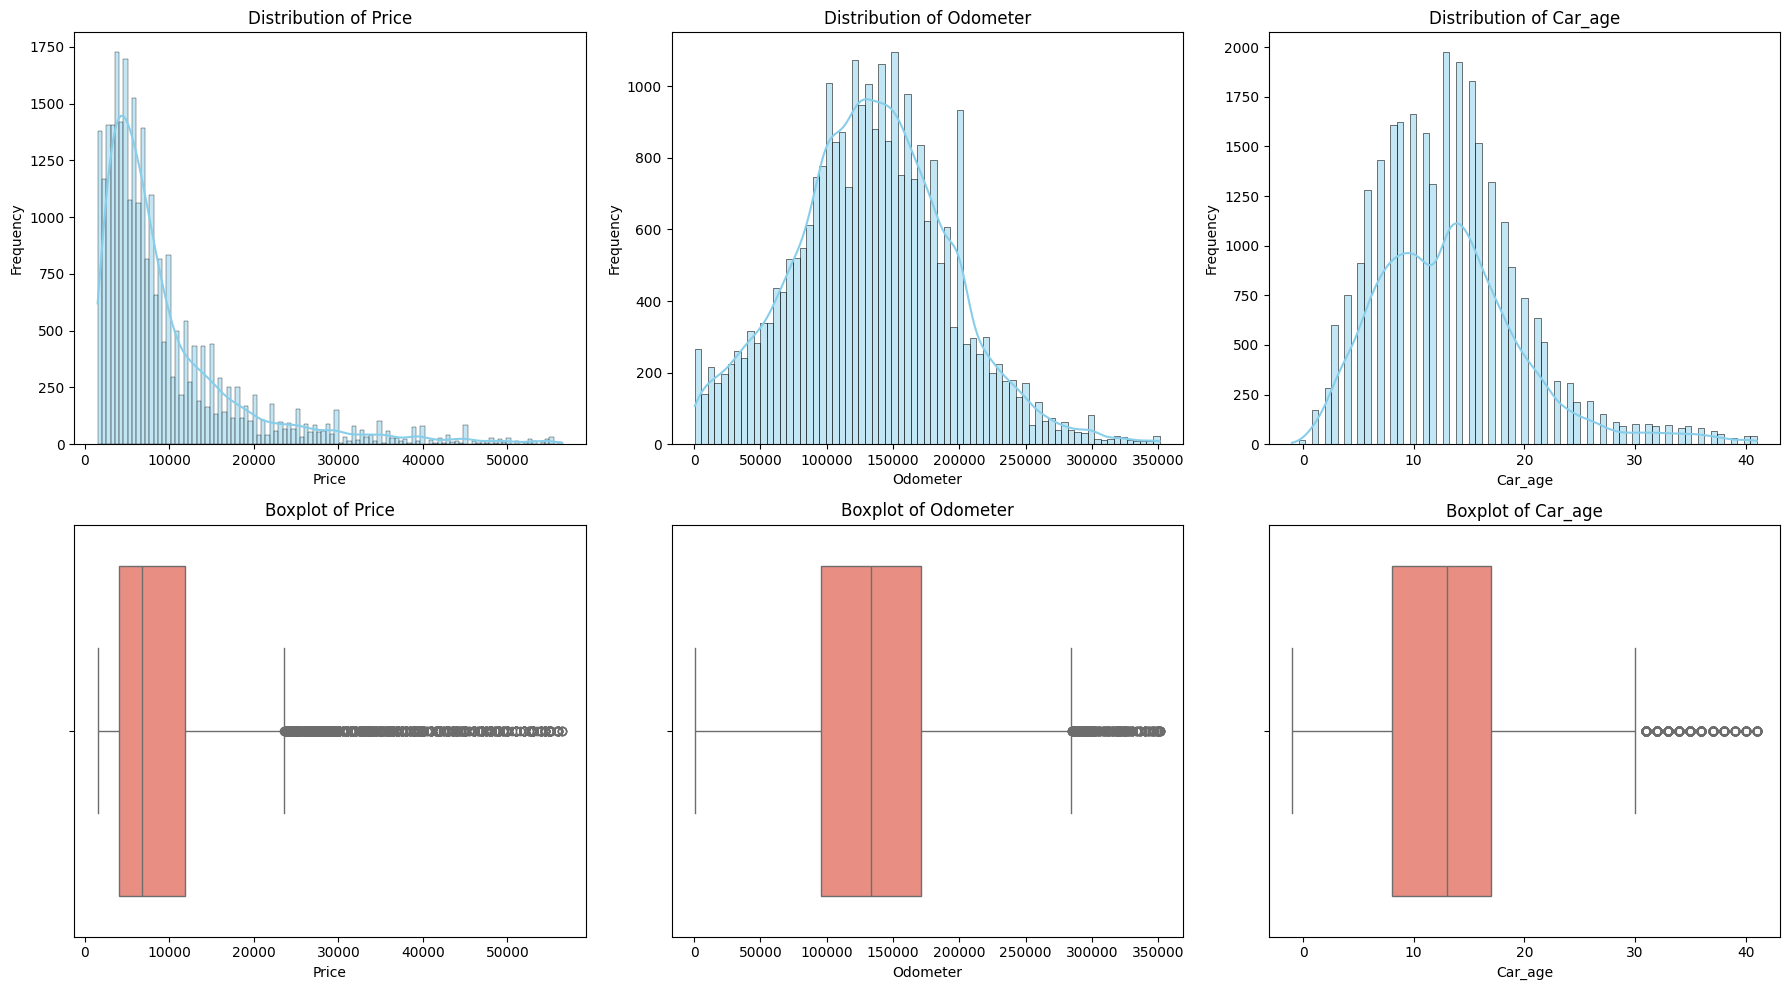

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# List of columns to visualize
cols = ['price', 'odometer', 'car_age']

# Row 1: Histograms with KDE
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Distribution of {col.capitalize()}')
    axes[0, i].set_xlabel(col.capitalize())
    axes[0, i].set_ylabel('Frequency')

# Row 2: Box plots
for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'Boxplot of {col.capitalize()}')
    axes[1, i].set_xlabel(col.capitalize())

plt.tight_layout()
plt.show()

### 3. Categorical Frequency Analysis

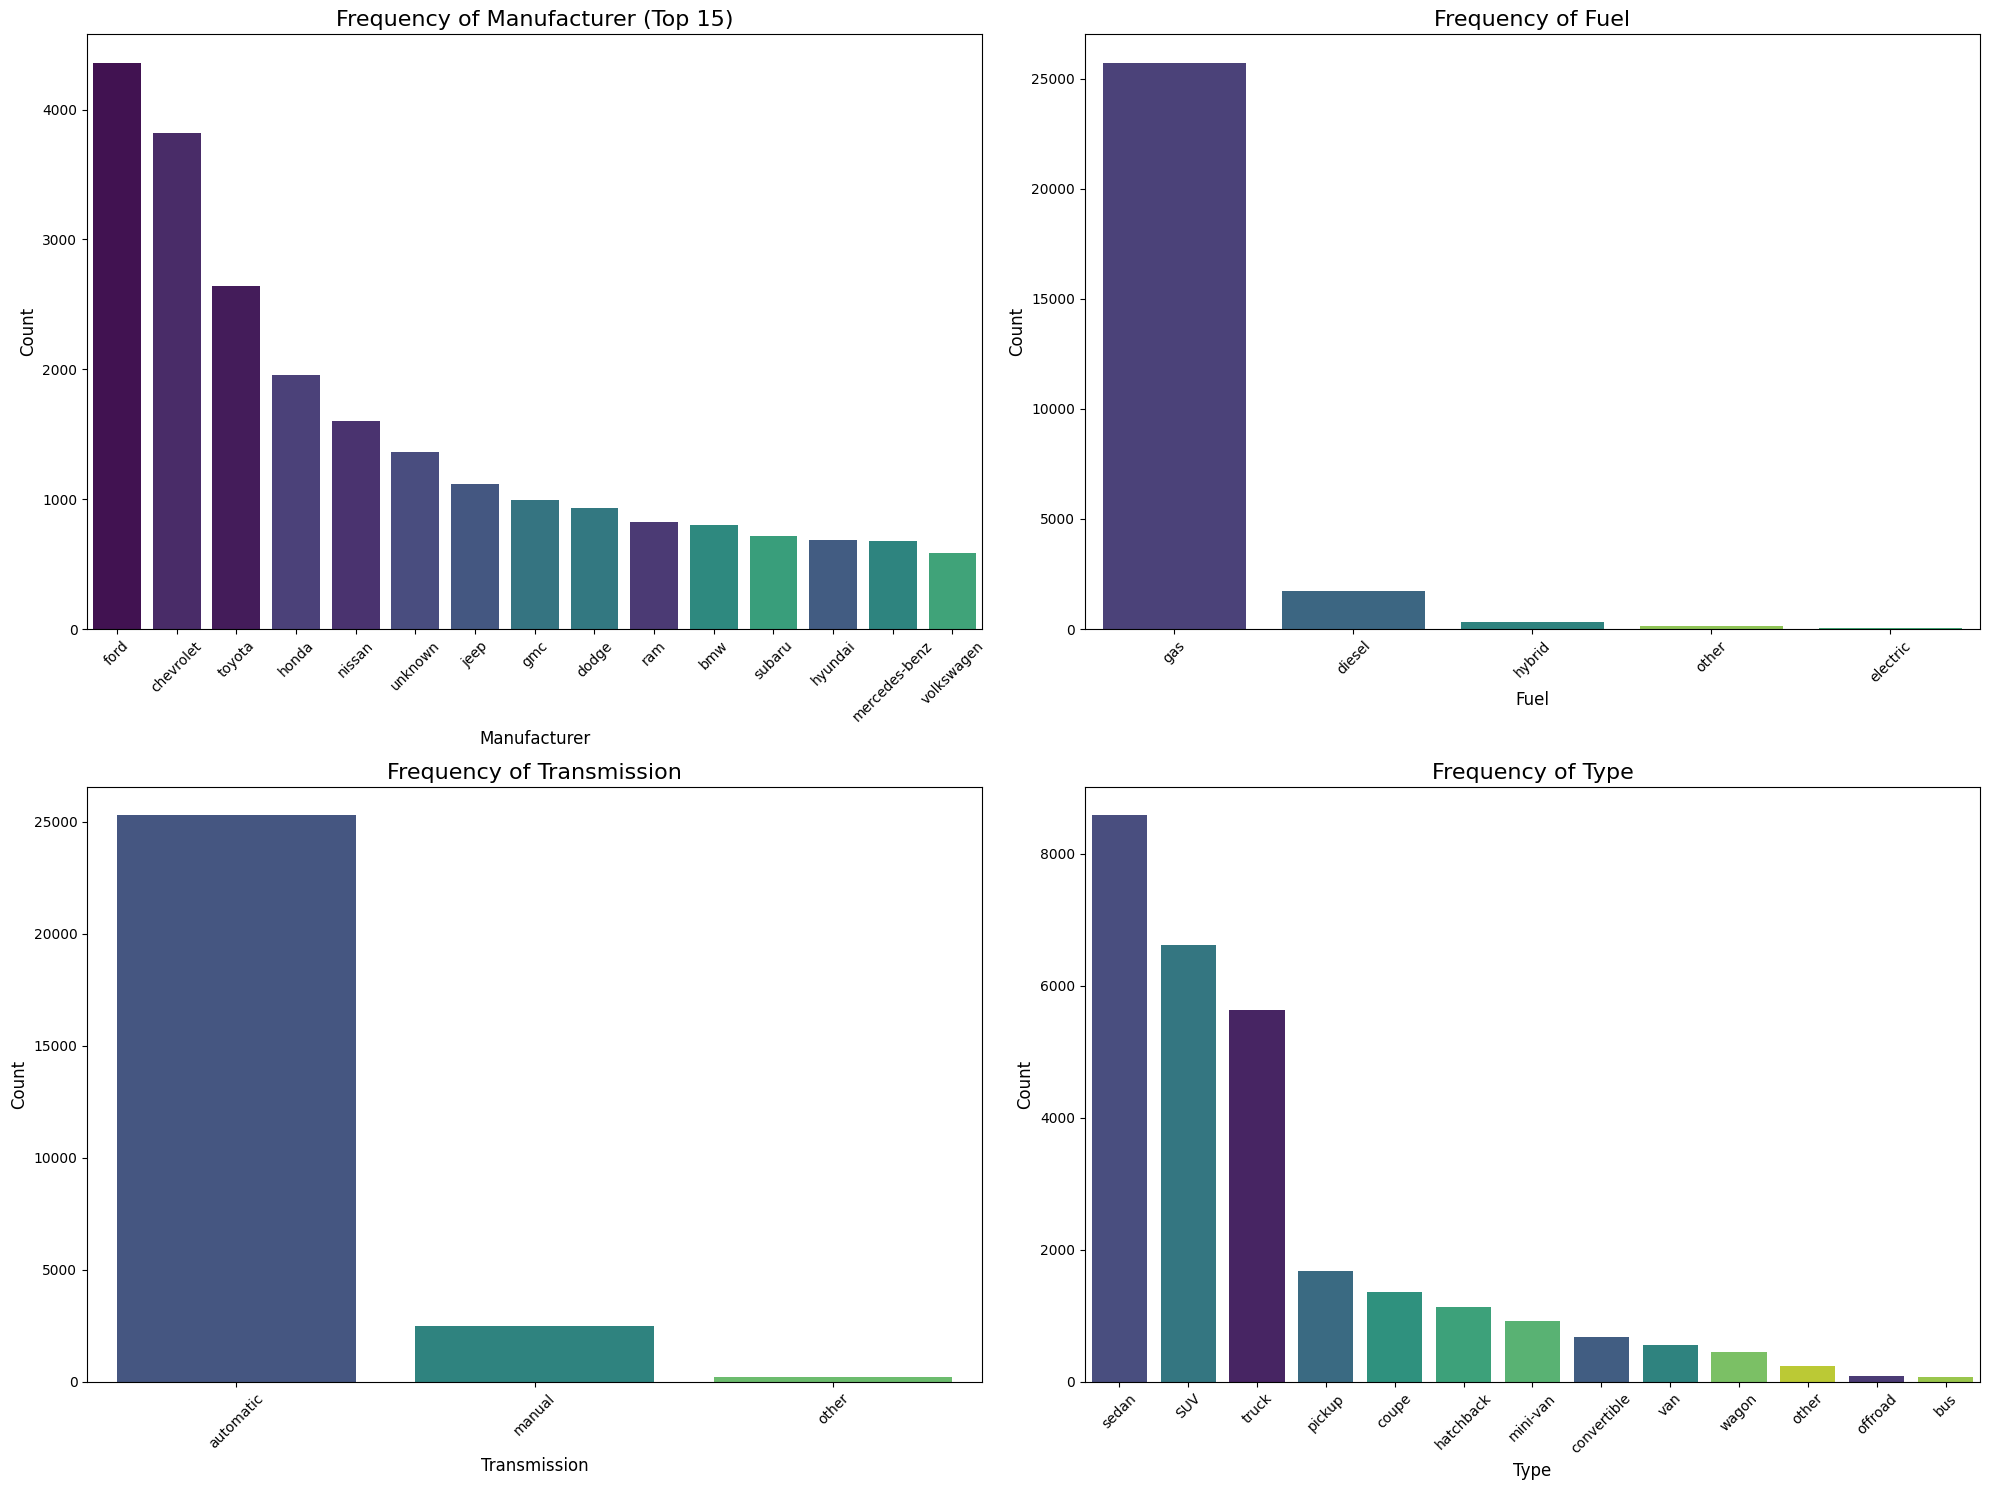

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define categorical columns
cat_cols = ['manufacturer', 'fuel', 'transmission', 'type']

# 2. Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 3 & 4. Get data for plotting (Top 15 for manufacturer, all for others)
    if col == 'manufacturer':
        order = df[col].value_counts().iloc[:15].index
        title_suffix = ' (Top 15)'
    else:
        order = df[col].value_counts().index
        title_suffix = ''

    # Plotting - updated to handle hue/palette warning
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='viridis', hue=col, legend=False)

    # 5. Customization
    axes[i].set_title(f'Frequency of {col.capitalize()}{title_suffix}', fontsize=16)
    axes[i].set_xlabel(col.capitalize(), fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

# 6. Adjust layout
plt.tight_layout()
plt.show()

### 4. Bivariate Price Relationship Analysis

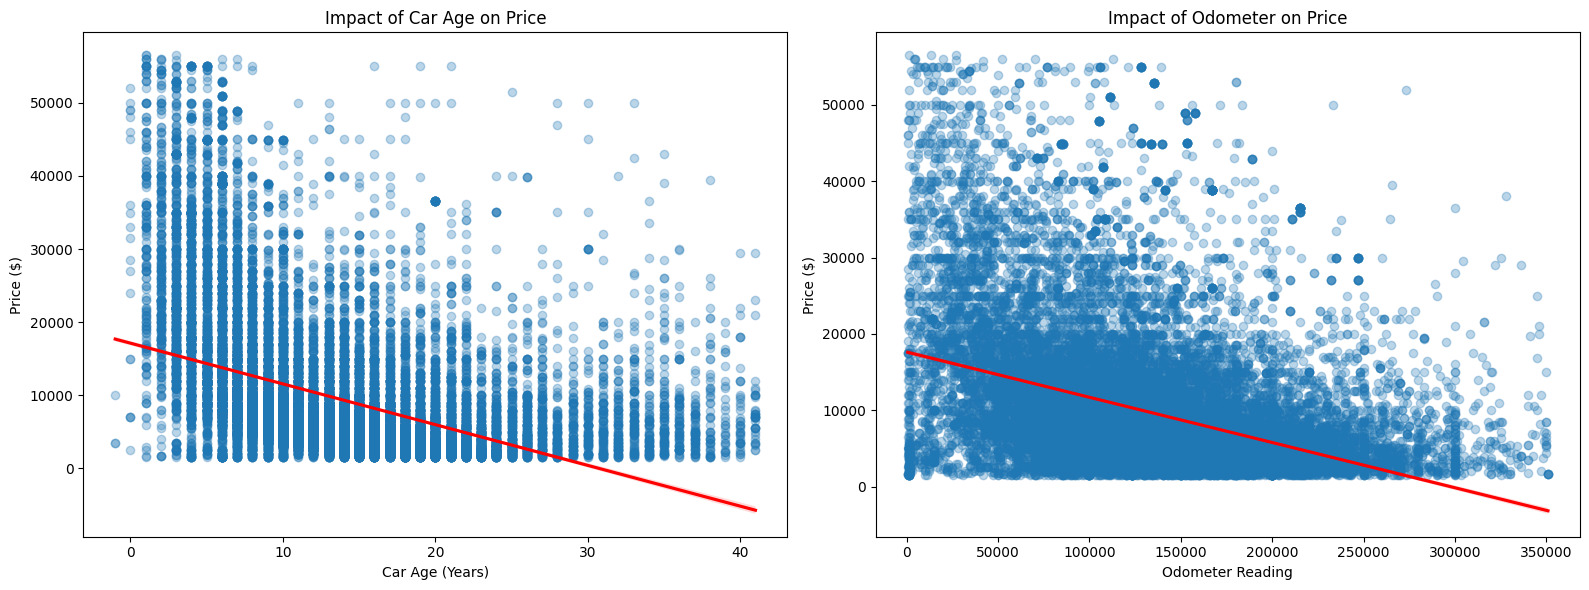

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set up a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Scatter plot of 'car_age' vs 'price' with regression line
sns.regplot(data=df, x='car_age', y='price', ax=ax1, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
ax1.set_title('Impact of Car Age on Price')
ax1.set_xlabel('Car Age (Years)')
ax1.set_ylabel('Price ($)')

# 3. Scatter plot of 'odometer' vs 'price' with regression line
sns.regplot(data=df, x='odometer', y='price', ax=ax2, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
ax2.set_title('Impact of Odometer on Price')
ax2.set_xlabel('Odometer Reading')
ax2.set_ylabel('Price ($)')

# 5. Use tight_layout and display
plt.tight_layout()
plt.show()

### 5. Correlation Analysis of Numerical Features

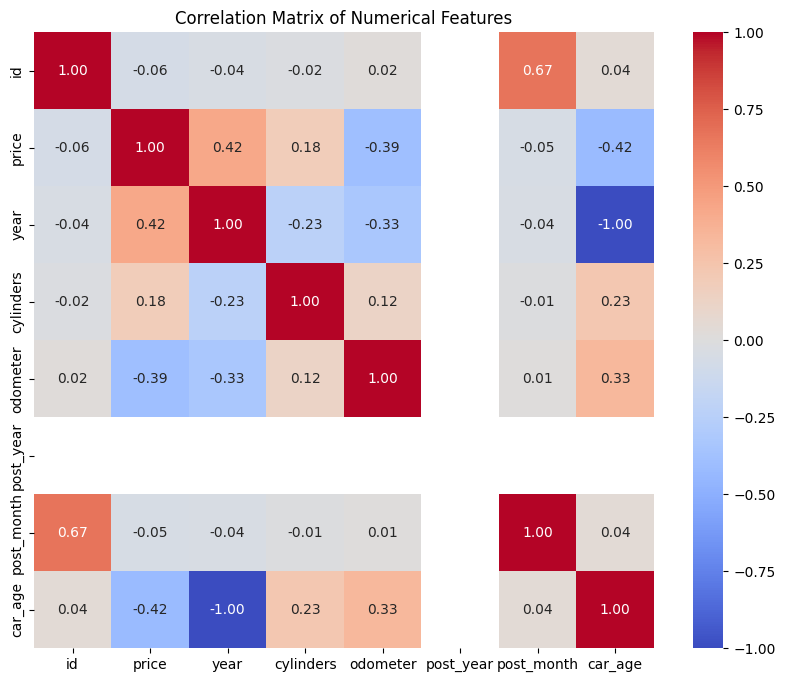

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numerical_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 4. Relationships Between Categorical and Numerical Features

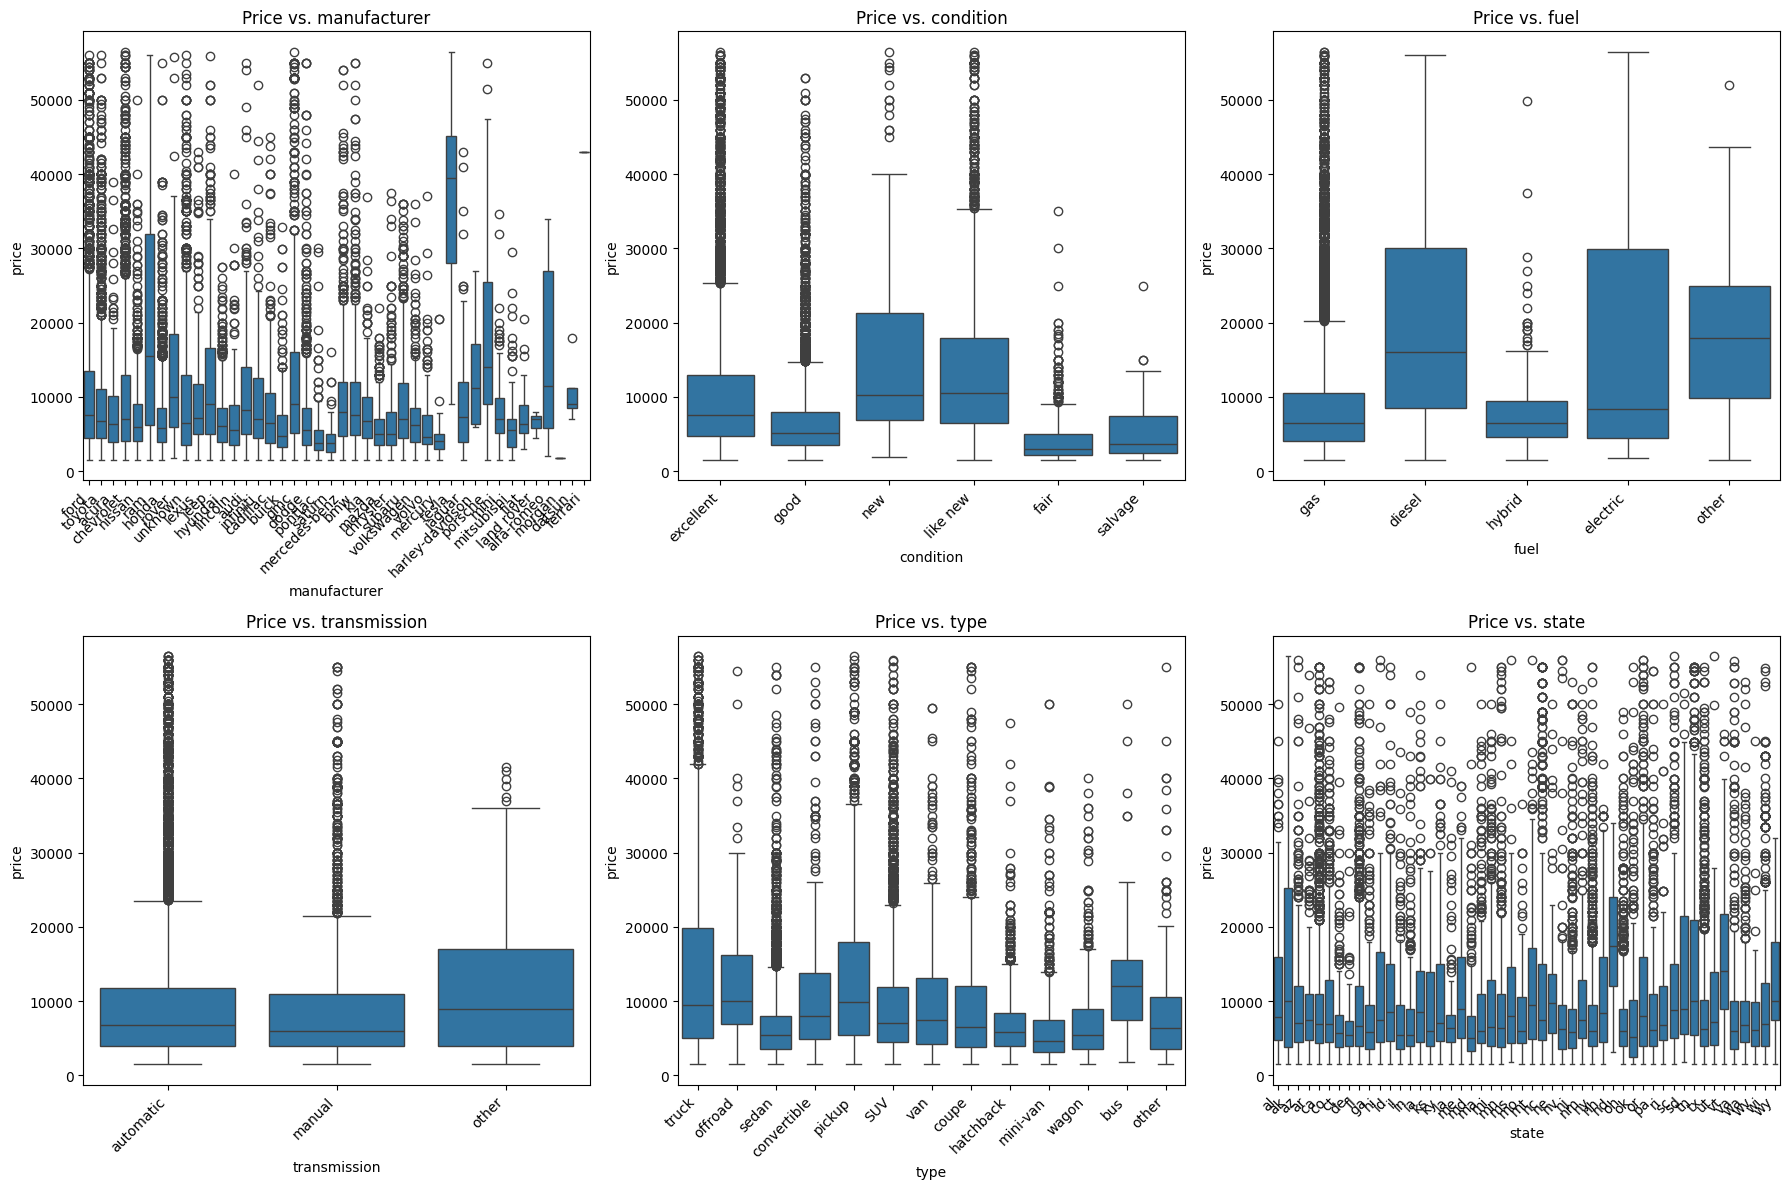

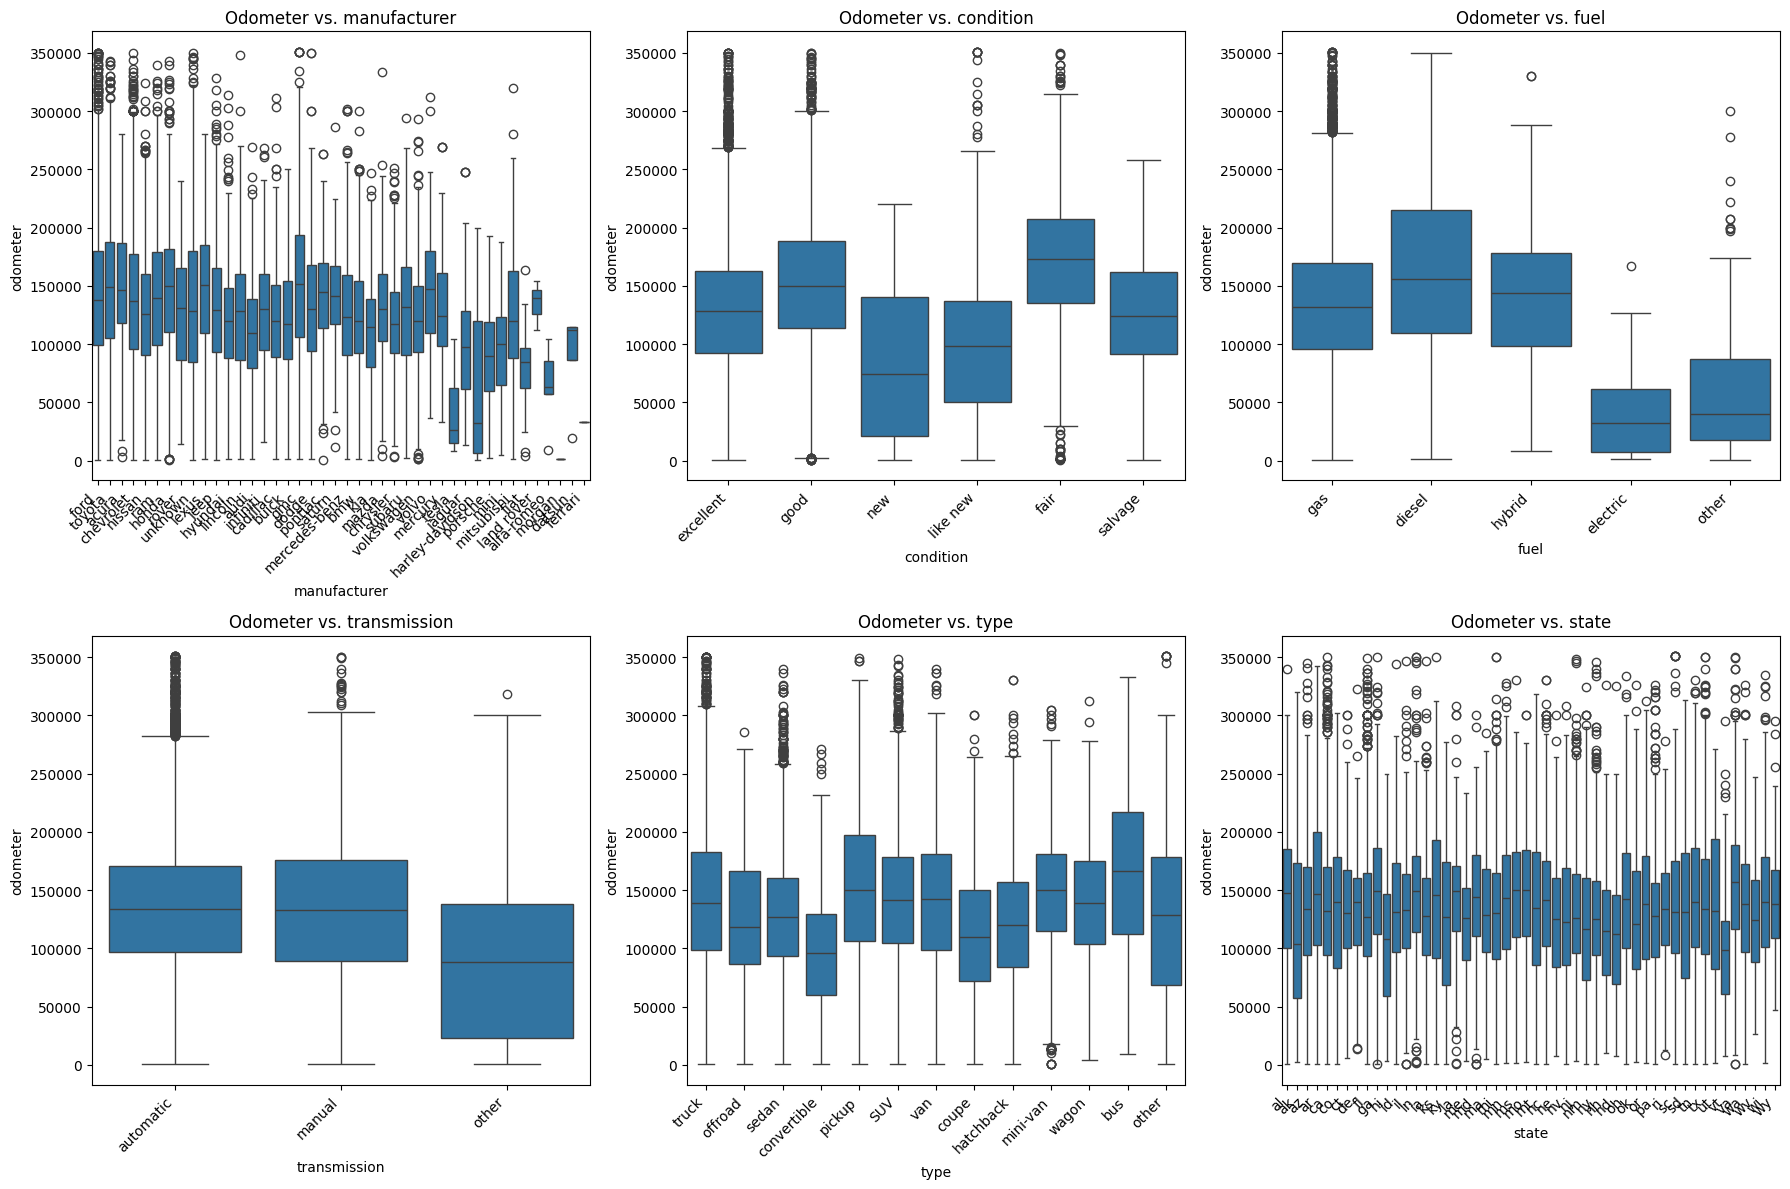

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_num_cols = ['manufacturer', 'condition', 'fuel', 'transmission', 'type', 'state']

plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df['price'], x=df[col])
    plt.title(f'Price vs. {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df['odometer'], x=df[col])
    plt.title(f'Odometer vs. {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary:

### Q&A

**What are the primary drivers of vehicle pricing in this dataset?**
The analysis identifies `car_age` and `odometer` as the most significant drivers of price. Both features exhibit a strong negative correlation with price, meaning that as a vehicle's age or mileage increases, its market value consistently decreases.

**Which categorical features should be prioritized for predictive modeling?**
Based on frequency analysis and distribution, `manufacturer`, `fuel`, `transmission`, and `type` are key categorical variables. Ford, Chevrolet, and Toyota are the most frequent brands, while 'gas' and 'automatic' are the dominant fuel and transmission types, respectively.

---

### Data Analysis Key Findings

*   **Negative Correlation with Price**: Both `car_age` and `odometer` show clear downward-sloping regression lines when plotted against `price`. Depreciation is most aggressive in the early years of a vehicle's life and at lower mileage intervals.
*   **Geospatial Distribution**: Mapping `lat` and `long` revealed that listings are concentrated in specific regional clusters. Price variations were observed across different longitudes and latitudes, suggesting that geographic location plays a role in vehicle valuation.
*   **Market Dominance**: The categorical analysis showed a heavy lean toward specific vehicle profiles:
    *   **Fuel**: Gasoline is the overwhelmingly dominant fuel type.
    *   **Transmission**: Automatic transmissions significantly outnumber manual options.
    *   **Manufacturer**: A few key manufacturers (Ford, Chevrolet, Toyota) represent a large portion of the market share.
*   **Data Quality and Outliers**: Univariate analysis using box plots for `price`, `odometer`, and `car_age` identified significant outliers, particularly in the high-price and high-mileage segments, which may require scaling or clipping before modeling.
*   **Correlation Coefficients**: The correlation heatmap confirmed that numerical features like `car_age` and `odometer` have the strongest linear relationship with price, while geospatial coordinates (`lat`, `long`) show much weaker direct linear correlations.

---

### Insights or Next Steps

*   **Feature Engineering**: Given the strong impact of `car_age`, creating additional features such as "is_vintage" (for older cars that might appreciate) or "miles_per_year" could improve predictive accuracy.
*   **Model Preparation**: Before training a model, categorical variables like `manufacturer` and `type` should be encoded (e.g., One-Hot Encoding), and numerical outliers identified in the box plots should be addressed to prevent skewed results.
